In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

print("All imports successful ✓")

All imports successful ✓


In [2]:
# Load the raw data
df = pd.read_csv('../data/city_day.csv')

print(f"Dataset shape: {df.shape}")
print(f"Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}")
print(f"\nColumns: {list(df.columns)}")

Dataset shape: (29531, 16)
Rows: 29,531  |  Columns: 16

Columns: ['City', 'Date', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI', 'AQI_Bucket']


In [3]:
# first 10 rows
df.head(10)

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN
5,Ahmedabad,2015-01-06,NaN,NaN,45.41,38.48,81.50,NaN,45.41,45.76,46.51,5.42,10.83,1.93,NaN,NaN
6,Ahmedabad,2015-01-07,NaN,NaN,112.16,40.62,130.77,NaN,112.16,32.28,33.47,0.00,0.00,0.00,NaN,NaN
7,Ahmedabad,2015-01-08,NaN,NaN,80.87,36.74,96.75,NaN,80.87,38.54,31.89,0.00,0.00,0.00,NaN,NaN
8,Ahmedabad,2015-01-09,NaN,NaN,29.16,31.00,48.00,NaN,29.16,58.68,25.75,0.00,0.00,0.00,NaN,NaN
9,Ahmedabad,2015-01-10,NaN,NaN,NaN,7.04,0.00,NaN,NaN,8.29,4.55,0.00,0.00,0.00,NaN,NaN


In [4]:
print("=" * 50)
print("DATASET INFORMATION")
print("=" * 50)
df.info()

DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City        29531 non-null  object 
 1   Date        29531 non-null  object 
 2   PM2.5       24933 non-null  float64
 3   PM10        18391 non-null  float64
 4   NO          25949 non-null  float64
 5   NO2         25946 non-null  float64
 6   NOx         25346 non-null  float64
 7   NH3         19203 non-null  float64
 8   CO          27472 non-null  float64
 9   SO2         25677 non-null  float64
 10  O3          25509 non-null  float64
 11  Benzene     23908 non-null  float64
 12  Toluene     21490 non-null  float64
 13  Xylene      11422 non-null  float64
 14  AQI         24850 non-null  float64
 15  AQI_Bucket  24850 non-null  object 
dtypes: float64(13), object(3)
memory usage: 3.6+ MB


In [5]:
print("Missing Values per Column:")
print("-" * 35)

missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).sort_values('Missing %', ascending=False)

print(missing_df[missing_df['Missing Count'] > 0])

Missing Values per Column:
-----------------------------------
            Missing Count  Missing %
Xylene              18109      61.32
PM10                11140      37.72
NH3                 10328      34.97
Toluene              8041      27.23
Benzene              5623      19.04
AQI                  4681      15.85
AQI_Bucket           4681      15.85
PM2.5                4598      15.57
NOx                  4185      14.17
O3                   4022      13.62
SO2                  3854      13.05
NO2                  3585      12.14
NO                   3582      12.13
CO                   2059       6.97


In [6]:
print("Basic Statistics:")
df.describe().round(2)

Basic Statistics:


,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI
count,24933.00,18391.00,25949.00,25946.00,25346.00,19203.00,27472.00,25677.00,25509.00,23908.00,21490.00,11422.00,24850.00
mean,67.45,118.13,17.57,28.56,32.31,23.48,2.25,14.53,34.49,3.28,8.70,3.07,166.46
std,64.66,90.61,22.79,24.47,31.65,25.68,6.96,18.13,21.69,15.81,19.97,6.32,140.70
min,0.04,0.01,0.02,0.01,0.00,0.01,0.00,0.01,0.01,0.00,0.00,0.00,13.00
25%,28.82,56.26,5.63,11.75,12.82,8.58,0.51,5.67,18.86,0.12,0.60,0.14,81.00
50%,48.57,95.68,9.89,21.69,23.52,15.85,0.89,9.16,30.84,1.07,2.97,0.98,118.00
75%,80.59,149.74,19.95,37.62,40.13,30.02,1.45,15.22,45.57,3.08,9.15,3.35,208.00
max,949.99,1000.00,390.68,362.21,467.63,352.89,175.81,193.86,257.73,455.03,454.85,170.37,2049.00


In [7]:
print(f"Total cities: {df['City'].nunique()}")
print(f"\nCity list:")
print(sorted(df['City'].unique()))

Total cities: 26

City list:
['Ahmedabad', 'Aizawl', 'Amaravati', 'Amritsar', 'Bengaluru', 'Bhopal', 'Brajrajnagar', 'Chandigarh', 'Chennai', 'Coimbatore', 'Delhi', 'Ernakulam', 'Gurugram', 'Guwahati', 'Hyderabad', 'Jaipur', 'Jorapokhar', 'Kochi', 'Kolkata', 'Lucknow', 'Mumbai', 'Patna', 'Shillong', 'Talcher', 'Thiruvananthapuram', 'Visakhapatnam']


In [8]:
print("AQI Summary:")
print(f"  Min AQI    : {df['AQI'].min():.1f}")
print(f"  Max AQI    : {df['AQI'].max():.1f}")
print(f"  Mean AQI   : {df['AQI'].mean():.1f}")
print(f"  Median AQI : {df['AQI'].median():.1f}")

print("\nAQI Category Distribution:")
# AQI categories as per Indian standard
def categorize_aqi(aqi):
    if aqi <= 50:   return 'Good'
    elif aqi <= 100: return 'Satisfactory'
    elif aqi <= 200: return 'Moderate'
    elif aqi <= 300: return 'Poor'
    elif aqi <= 400: return 'Very Poor'
    else:            return 'Severe'

df['AQI_Category'] = df['AQI'].apply(categorize_aqi)
print(df['AQI_Category'].value_counts())

AQI Summary:
  Min AQI    : 13.0
  Max AQI    : 2049.0
  Mean AQI   : 166.5
  Median AQI : 118.0

AQI Category Distribution:
AQI_Category
Moderate        8829
Satisfactory    8224
Severe          6019
Poor            2781
Very Poor       2337
Good            1341
Name: count, dtype: int64


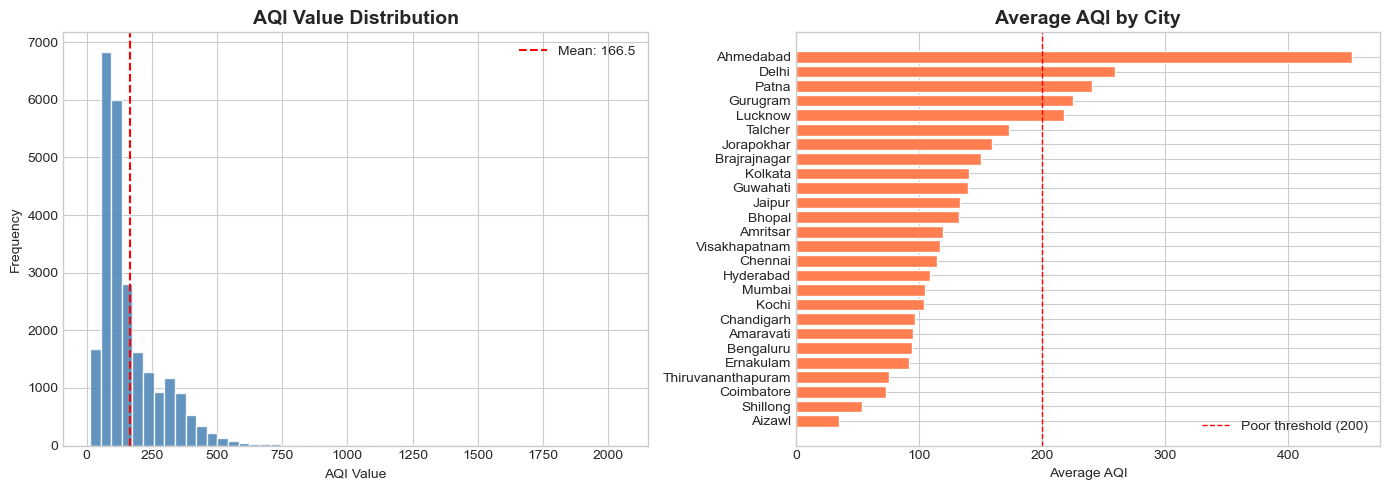

Plot saved to visualizations/ ✓


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: AQI distribution
axes[0].hist(df['AQI'].dropna(), bins=50, color='steelblue', 
             edgecolor='white', alpha=0.85)
axes[0].set_title('AQI Value Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('AQI Value')
axes[0].set_ylabel('Frequency')
axes[0].axvline(df['AQI'].mean(), color='red', 
                linestyle='--', label=f"Mean: {df['AQI'].mean():.1f}")
axes[0].legend()

# Plot 2: Average AQI per city
city_aqi = df.groupby('City')['AQI'].mean().sort_values(ascending=True)
axes[1].barh(city_aqi.index, city_aqi.values, color='coral', edgecolor='white')
axes[1].set_title('Average AQI by City', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Average AQI')
axes[1].axvline(200, color='red', linestyle='--', 
                linewidth=1, label='Poor threshold (200)')
axes[1].legend()

plt.tight_layout()
plt.savefig('../visualizations/01_aqi_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved to visualizations/ ✓")